# Principal Component Analysis (PCA) Lab

This fully worked notebook teaches **Principal Component Analysis (PCA)** using the **Wisconsin Breast Cancer dataset**, a real biomedical dataset available in `scikit-learn`.

## Learning goals
By the end of this notebook, you should be able to:

- explain why PCA is useful for high-dimensional biological data
- standardize features before PCA
- compute PCA with `scikit-learn`
- interpret **explained variance**
- visualize samples in the **PC1-PC2 plane**
- interpret **loadings** to understand which variables drive each principal component
- compare PCA-based dimensionality reduction with the original feature space

## Why this dataset?
The Wisconsin Breast Cancer dataset contains measurements computed from digitized images of fine needle aspirates of breast masses. It is widely used in biomedical data analysis and is a good PCA teaching example because:

- it has multiple correlated quantitative features
- it has a biologically meaningful class label
- it is large enough to be realistic, but small enough to understand completely

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Make plots readable
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

## 1. Load the real dataset
We begin by loading the breast cancer dataset and converting it into a pandas DataFrame.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", data.target_names)
X.head()

Feature matrix shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Dataset summary
Each row is a patient/sample, and each column is a measured feature.

The target values are:
- `0` = malignant
- `1` = benign

In [3]:
class_counts = y.value_counts().sort_index()
class_names = {i: name for i, name in enumerate(data.target_names)}

summary_df = pd.DataFrame({
    "class_index": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})
summary_df

,class_index,class_name,count
0,0,malignant,212
1,1,benign,357


## 2. Basic exploration

Before PCA, it is helpful to inspect the scale of the variables.

In [4]:
X.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


### Important observation
The variables are on different scales. Some have much larger numerical ranges than others.

This matters because PCA is based on **variance**. If we do not scale the variables, features with large units can dominate the principal components.

## 3. Correlation structure

PCA is especially useful when variables are correlated and therefore contain redundant information.

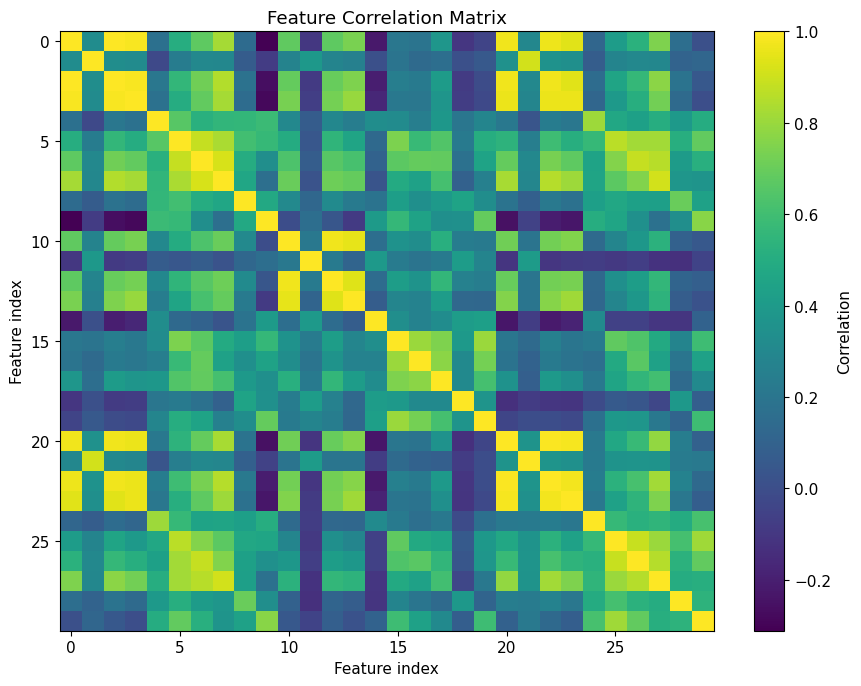

In [5]:
corr = X.corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, label="Correlation")
plt.title("Feature Correlation Matrix")
plt.xlabel("Feature index")
plt.ylabel("Feature index")
plt.tight_layout()
plt.show()

You should see substantial correlation among many features. This is exactly the kind of structure PCA can exploit.

## 4. Standardize the data

Because the features are measured on different scales, we standardize them so that each feature has mean 0 and standard deviation 1.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean of first 5 scaled features:", X_scaled[:, :5].mean(axis=0))
print("Std of first 5 scaled features:", X_scaled[:, :5].std(axis=0))

Mean of first 5 scaled features: [-3.16286735e-15 -6.53060890e-15 -7.07889127e-16 -8.79983452e-16
  6.13217737e-15]
Std of first 5 scaled features: [1. 1. 1. 1. 1.]


## 5. Fit PCA on the standardized data

We first fit PCA keeping all components so that we can inspect how much variance each component explains.

In [5]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

explained_df = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(explained_var_ratio) + 1)],
    "Explained variance ratio": explained_var_ratio,
    "Cumulative explained variance": cumulative_var_ratio
})

explained_df.head(10)

,PC,Explained variance ratio,Cumulative explained variance
0,PC1,0.442720,0.442720
1,PC2,0.189712,0.632432
2,PC3,0.093932,0.726364
3,PC4,0.066021,0.792385
4,PC5,0.054958,0.847343
5,PC6,0.040245,0.887588
6,PC7,0.022507,0.910095
7,PC8,0.015887,0.925983
8,PC9,0.013896,0.939879
9,PC10,0.011690,0.951569


## 6. Scree plot and cumulative explained variance
These plots help determine how many principal components to keep.

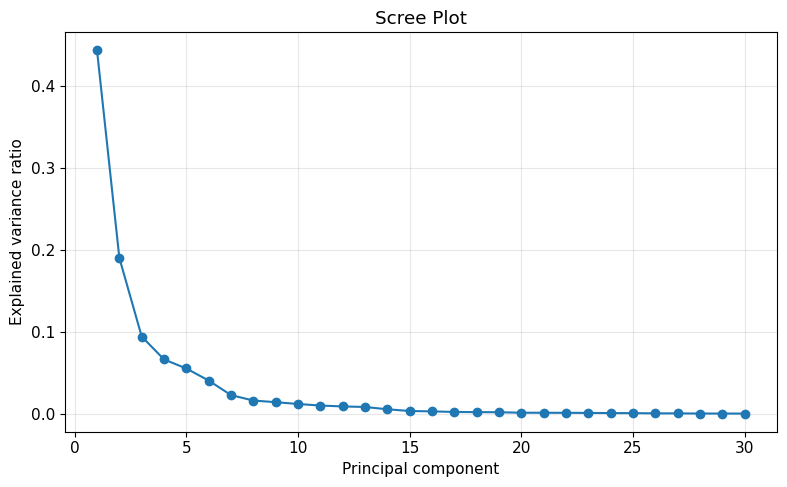

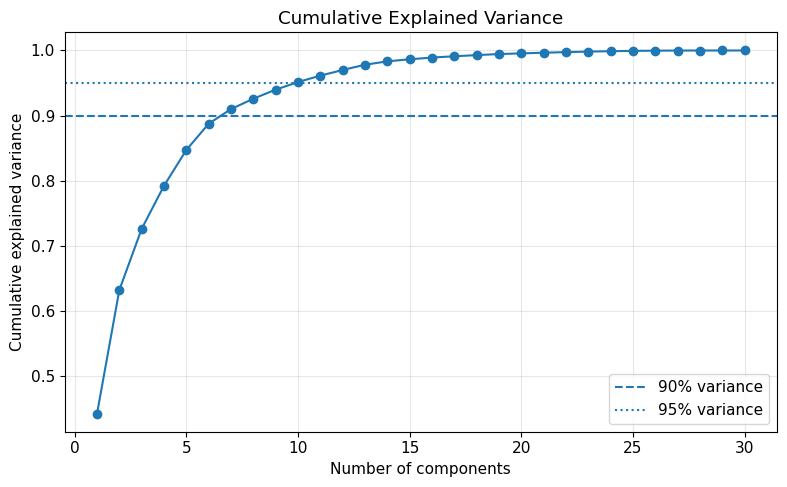

In [8]:
# Scree plot
plt.figure()
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Scree Plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cumulative explained variance
plt.figure()
plt.plot(range(1, len(cumulative_var_ratio) + 1), cumulative_var_ratio, marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle=":", label="95% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
n_components_90 = np.argmax(cumulative_var_ratio >= 0.90) + 1
n_components_95 = np.argmax(cumulative_var_ratio >= 0.95) + 1

print(f"Number of PCs needed for >= 90% variance: {n_components_90}")
print(f"Number of PCs needed for >= 95% variance: {n_components_95}")

Number of PCs needed for >= 90% variance: 7
Number of PCs needed for >= 95% variance: 10


### Interpretation
Often in teaching, students expect that most of the information requires many dimensions. But in correlated biomedical datasets, a relatively small number of principal components can often explain much of the total variance.

## 7. Fit PCA with 2 components for visualization
Now we project the data into 2D so we can visualize the samples in the PC1-PC2 plane.

In [10]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_2_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_2_df["target"] = y
pca_2_df["class_name"] = pca_2_df["target"].map({0: "malignant", 1: "benign"})

pca_2_df.head()

,PC1,PC2,target,class_name
0,9.192837,1.948583,0,malignant
1,2.387802,-3.768172,0,malignant
2,5.733896,-1.075174,0,malignant
3,7.122953,10.275589,0,malignant
4,3.935302,-1.948072,0,malignant


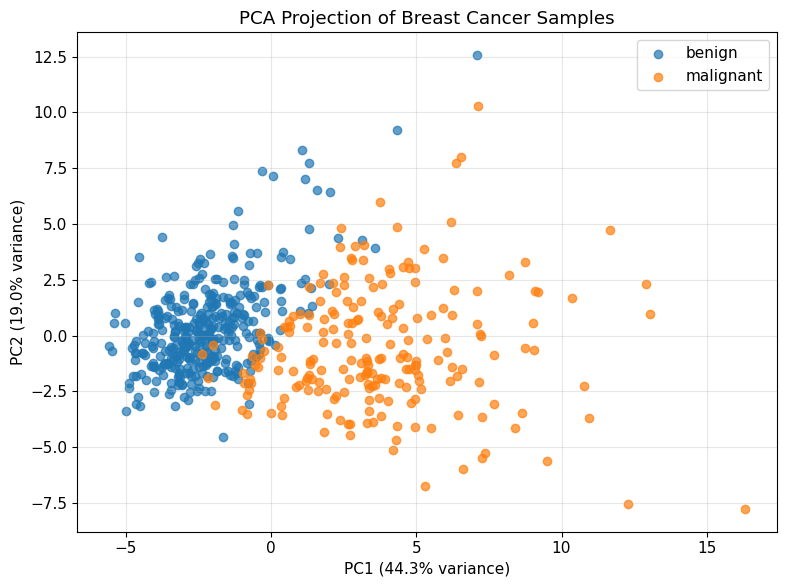

In [11]:
plt.figure(figsize=(8, 6))

for cls in sorted(pca_2_df["class_name"].unique()):
    subset = pca_2_df[pca_2_df["class_name"] == cls]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.7, label=cls)

plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection of Breast Cancer Samples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of the PCA scatter plot
This figure shows each sample projected onto the first two principal components.

Questions to ask students:
- Do the classes separate in PCA space?
- Is the separation perfect or partial?
- Why might unsupervised PCA still reveal class structure even though it does not use the labels?

## 8. Principal component loadings

The **loadings** show how strongly each original variable contributes to each principal component.

For `scikit-learn`, the rows of `pca.components_` are the principal directions.

In [12]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=X.columns,
    columns=["PC1_loading", "PC2_loading"]
)

loadings.head(10)

,PC1_loading,PC2_loading
mean radius,0.218902,-0.233857
mean texture,0.103725,-0.059706
mean perimeter,0.227537,-0.215181
mean area,0.220995,-0.231077
mean smoothness,0.142590,0.186113
mean compactness,0.239285,0.151892
mean concavity,0.258400,0.060165
mean concave points,0.260854,-0.034768
mean symmetry,0.138167,0.190349
mean fractal dimension,0.064363,0.366575


### Top features contributing to PC1
We sort by the absolute magnitude of the loading.

In [13]:
top_pc1 = loadings.reindex(loadings["PC1_loading"].abs().sort_values(ascending=False).index).head(10)
top_pc1

,PC1_loading,PC2_loading
mean concave points,0.260854,-0.034768
mean concavity,0.258400,0.060165
worst concave points,0.250886,-0.008257
mean compactness,0.239285,0.151892
worst perimeter,0.236640,-0.199878
worst concavity,0.228768,0.097964
worst radius,0.227997,-0.219866
mean perimeter,0.227537,-0.215181
worst area,0.224871,-0.219352
mean area,0.220995,-0.231077


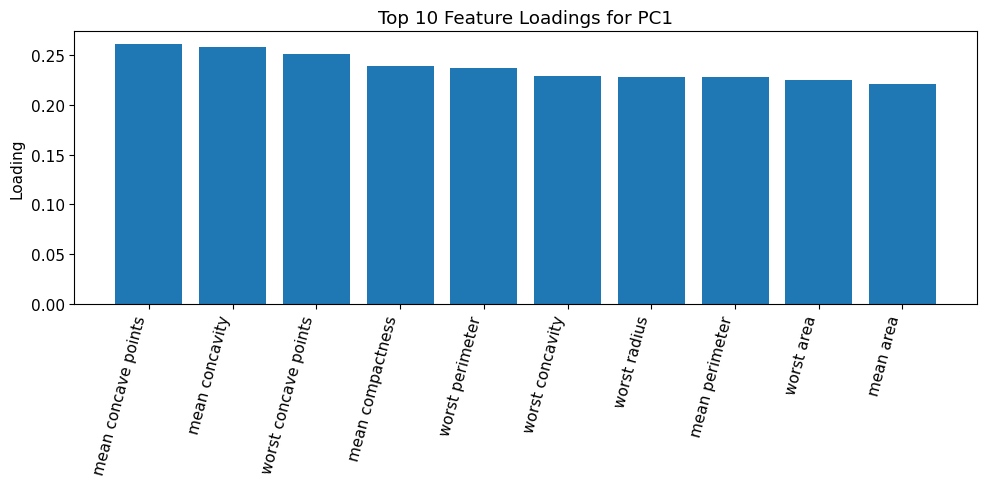

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(top_pc1.index, top_pc1["PC1_loading"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Loading")
plt.title("Top 10 Feature Loadings for PC1")
plt.tight_layout()
plt.show()

### Top features contributing to PC2

In [16]:
top_pc2 = loadings.reindex(loadings["PC2_loading"].abs().sort_values(ascending=False).index).head(10)
top_pc2

,PC1_loading,PC2_loading
mean fractal dimension,0.064363,0.366575
fractal dimension error,0.102568,0.280092
worst fractal dimension,0.131784,0.275339
mean radius,0.218902,-0.233857
compactness error,0.170393,0.232716
mean area,0.220995,-0.231077
worst radius,0.227997,-0.219866
worst area,0.224871,-0.219352
mean perimeter,0.227537,-0.215181
smoothness error,0.014531,0.204430


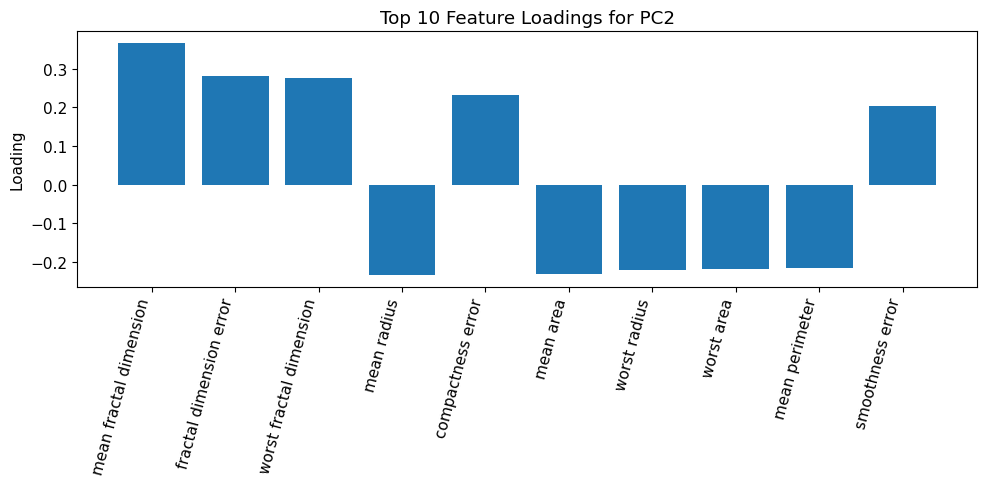

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(top_pc2.index, top_pc2["PC2_loading"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Loading")
plt.title("Top 10 Feature Loadings for PC2")
plt.tight_layout()
plt.show()

## 9. A simple loading vector overlay

This is a basic teaching version of a PCA loading plot. We overlay arrows for the most influential variables on top of the sample scores.

Note:
- The arrows indicate the directions in which variables increase
- Longer arrows suggest stronger contribution in the PC1-PC2 plane
- This is not a full formal biplot, but it is very helpful pedagogically

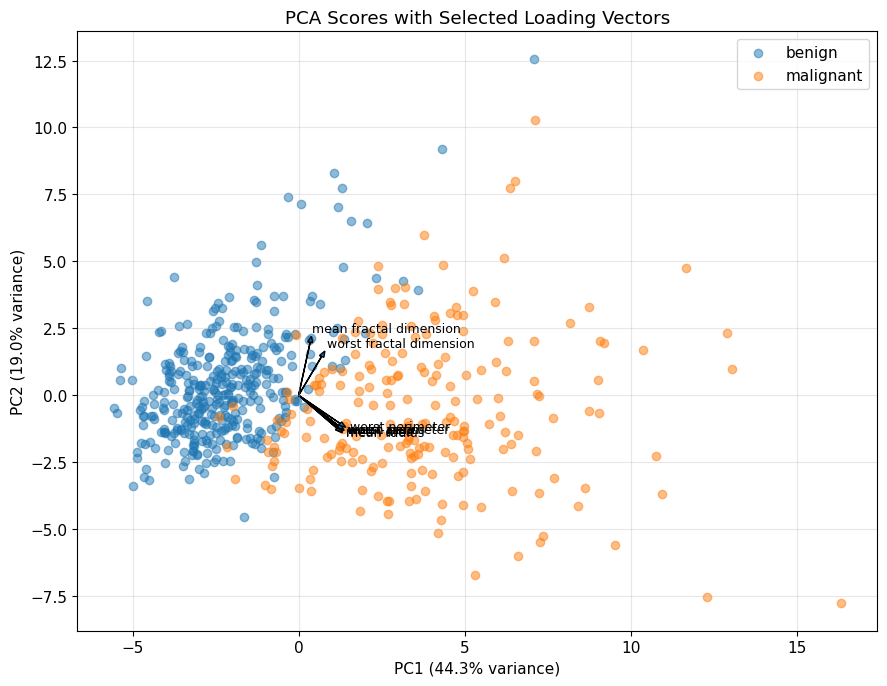

In [18]:
# Select a few strongest features overall in PC1-PC2 plane
loading_strength = np.sqrt(loadings["PC1_loading"]**2 + loadings["PC2_loading"]**2)
top_features = loading_strength.sort_values(ascending=False).head(8).index

plt.figure(figsize=(9, 7))
for cls in sorted(pca_2_df["class_name"].unique()):
    subset = pca_2_df[pca_2_df["class_name"] == cls]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.5, label=cls)

# scale arrows for visualization
arrow_scale = 6
for feature in top_features:
    x_loading = loadings.loc[feature, "PC1_loading"]
    y_loading = loadings.loc[feature, "PC2_loading"]
    plt.arrow(0, 0, arrow_scale*x_loading, arrow_scale*y_loading,
              head_width=0.15, length_includes_head=True)
    plt.text(arrow_scale*x_loading*1.08, arrow_scale*y_loading*1.08, feature, fontsize=9)

plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Scores with Selected Loading Vectors")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Reconstruction idea

PCA can be viewed as approximating the original data with fewer dimensions.

Here we reduce the data to 2 dimensions and then reconstruct it back into the original feature space.

In [19]:
X_reconstructed_scaled = pca_2.inverse_transform(X_pca_2)

reconstruction_mse = np.mean((X_scaled - X_reconstructed_scaled) ** 2)
print(f"Mean squared reconstruction error using 2 PCs: {reconstruction_mse:.4f}")

Mean squared reconstruction error using 2 PCs: 0.3676


A lower reconstruction error means the reduced representation preserves more of the original information.

## 11. Optional supervised comparison:
## Logistic regression on original features vs PCA-reduced features

PCA is unsupervised and is not guaranteed to maximize classification accuracy. But it is often useful to compare model performance before and after dimensionality reduction.

In [20]:
# Original standardized features
pipe_original = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

# Standardization + PCA + logistic regression
pipe_pca10 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("model", LogisticRegression(max_iter=5000))
])

scores_original = cross_val_score(pipe_original, X, y, cv=5, scoring="accuracy")
scores_pca10 = cross_val_score(pipe_pca10, X, y, cv=5, scoring="accuracy")

comparison_df = pd.DataFrame({
    "Model": ["Logistic regression on original features", "Logistic regression on first 10 PCs"],
    "Mean CV accuracy": [scores_original.mean(), scores_pca10.mean()],
    "Std CV accuracy": [scores_original.std(), scores_pca10.std()]
})

comparison_df

,Model,Mean CV accuracy,Std CV accuracy
0,Logistic regression on original features,0.980686,0.006539
1,Logistic regression on first 10 PCs,0.980671,0.006556


### Discussion
This comparison helps students see an important practical lesson:

- PCA may reduce dimensionality substantially
- but unsupervised dimensionality reduction does **not automatically improve predictive accuracy**
- sometimes it preserves accuracy well; sometimes it loses useful class information

## 12. Key takeaways

1. PCA finds new orthogonal directions that explain maximal variance.
2. PCA should usually be performed on **standardized** data when variables are on different scales.
3. The first few PCs often capture substantial structure in correlated biomedical data.
4. A PCA score plot helps visualize sample relationships.
5. Loadings help interpret which original variables drive each component.
6. PCA is unsupervised, so high explained variance does not necessarily mean best classification performance.

---

## Suggested exercises

1. Fit PCA **without scaling** and compare the results.
2. How many PCs are needed to explain 80%, 90%, and 95% of the variance?
3. Which features contribute most strongly to PC1?
4. Does PCA separate malignant and benign samples well in the first two PCs?
5. Compare logistic regression accuracy using:
   - all original features
   - first 2 PCs
   - first 5 PCs
   - first 10 PCs

---

## Instructor note
This notebook is especially suitable as a bridge into:
- singular value decomposition (SVD)
- clustering after dimensionality reduction
- t-SNE and UMAP as nonlinear alternatives
- batch effects and outlier detection in omics data